In [22]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts.analysis_utils import get_density2d, make_levels, add_colorbar, add_crosshair

In [41]:
data = np.loadtxt('all_real_output.txt')
#data = data[np.isin(data[:, 2], [20251113.0, 20251116.0, 20251119.0])]
print(f'Number of pointings: {len(np.unique(data[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data[data[:, -1] > 0.])/len(data)):.2f}%')
print(f'Number of injections: {len(data)}')
RA = data[:, 0]
Dec = data[:, 1]
f = data[:, 4]
DM = data[:, 5]
S = data[:, 6]
TPA_idx = data[:, 3].astype('int')
fwhm_array = np.load('../profiles/TPA_fwhm.npy')
fwhm = fwhm_array[TPA_idx]
data[:, 7] = fwhm

Number of pointings: 9909
Number of days: 6
Total fraction of recovered injections: 26.27%
Number of injections: 149992


In [42]:
#RA, Dec, Date, TPA_idx, f, DM, flux, fwhm, predicted_sigma...
sigma_mask = data[:, 8] > 6. #threshold for candidates 
missed_mask = data[:, -1] < 0. 
should_have_detected = data[sigma_mask & missed_mask]
print(f'{len(should_have_detected) / len(data[sigma_mask]) * 100:.1f}% of injections with a \
predicted sigma > 6 were not retrieved by the search pipeline.')

37.7% of injections with a predicted sigma > 6 were not retrieved by the search pipeline.


In [43]:
RA_bins = np.arange(min(RA), max(RA), 0.5)
Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1001)
DM_bins = np.arange(min(DM), 400, 1.)
S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 101)
fwhm_bins = np.logspace(np.log10(min(fwhm)), -0.95, 101)

RA_dev = 10
Dec_dev = 10
f_dev = 100
DM_dev = 100
S_dev = 10
FWHM_dev = 10

In [44]:
dm_f_injected, dm_f_missed = get_density2d(data, 5, 4, DM_bins, f_bins, type = 'missed')
dm_f_inj_smooth = gaussian_filter(dm_f_injected, (DM_dev, f_dev))
dm_f_inj_p = dm_f_inj_smooth / np.sum(dm_f_inj_smooth)
dm_f_miss_smooth = gaussian_filter(dm_f_missed, (DM_dev, f_dev))
dm_f_miss_p = dm_f_miss_smooth / dm_f_inj_smooth

dm_s_injected, dm_s_missed = get_density2d(data, 5, 6, DM_bins, S_bins, type = 'missed')
dm_s_inj_smooth = gaussian_filter(dm_s_injected, (DM_dev, S_dev))
dm_s_inj_p = dm_s_inj_smooth / np.sum(dm_s_inj_smooth)
dm_s_miss_smooth = gaussian_filter(dm_s_missed, (DM_dev, S_dev))
dm_s_miss_p = dm_s_miss_smooth / dm_s_inj_smooth

s_f_injected, s_f_missed = get_density2d(data, 6, 4, S_bins, f_bins, type = 'missed')
s_f_inj_smooth = gaussian_filter(s_f_injected, (S_dev, f_dev))
s_f_inj_p = s_f_inj_smooth / np.sum(s_f_inj_smooth)
s_f_miss_smooth = gaussian_filter(s_f_missed, (S_dev, f_dev))
s_f_miss_p = s_f_miss_smooth / s_f_inj_smooth

s_fwhm_injected, s_fwhm_missed = get_density2d(data, 6, 7, S_bins, fwhm_bins, type = 'missed')
s_fwhm_inj_smooth = gaussian_filter(s_fwhm_injected, (S_dev, FWHM_dev))
s_fwhm_inj_p = s_fwhm_inj_smooth / np.sum(s_fwhm_inj_smooth)
s_fwhm_miss_smooth = gaussian_filter(s_fwhm_missed, (S_dev, FWHM_dev))
s_fwhm_miss_p = s_fwhm_miss_smooth / s_fwhm_inj_smooth

dm_fwhm_injected, dm_fwhm_missed = get_density2d(data, 5, 7, DM_bins, fwhm_bins, type = 'missed')
dm_fwhm_inj_smooth = gaussian_filter(dm_fwhm_injected, (DM_dev, FWHM_dev))
dm_fwhm_inj_p = dm_fwhm_inj_smooth / np.sum(dm_fwhm_inj_smooth)
dm_fwhm_miss_smooth = gaussian_filter(dm_fwhm_missed, (DM_dev, FWHM_dev))
dm_fwhm_miss_p = dm_fwhm_miss_smooth / dm_fwhm_inj_smooth

fwhm_f_injected, fwhm_f_missed = get_density2d(data, 7, 4, fwhm_bins, f_bins, type = 'missed')
fwhm_f_inj_smooth = gaussian_filter(fwhm_f_injected, (FWHM_dev, f_dev))
fwhm_f_inj_p = fwhm_f_inj_smooth / np.sum(fwhm_f_inj_smooth)
fwhm_f_miss_smooth = gaussian_filter(fwhm_f_missed, (FWHM_dev, f_dev))
fwhm_f_miss_p = fwhm_f_miss_smooth / fwhm_f_inj_smooth

dm_fwhm_inj_p[np.isnan(dm_fwhm_inj_p)] = 1e-16
dm_fwhm_inj_p[dm_fwhm_inj_p == 0] = 1e-16
dm_fwhm_miss_p[np.isnan(dm_fwhm_miss_p)] = 0.00041
dm_fwhm_miss_p[dm_fwhm_miss_p == 0] = 0.00041

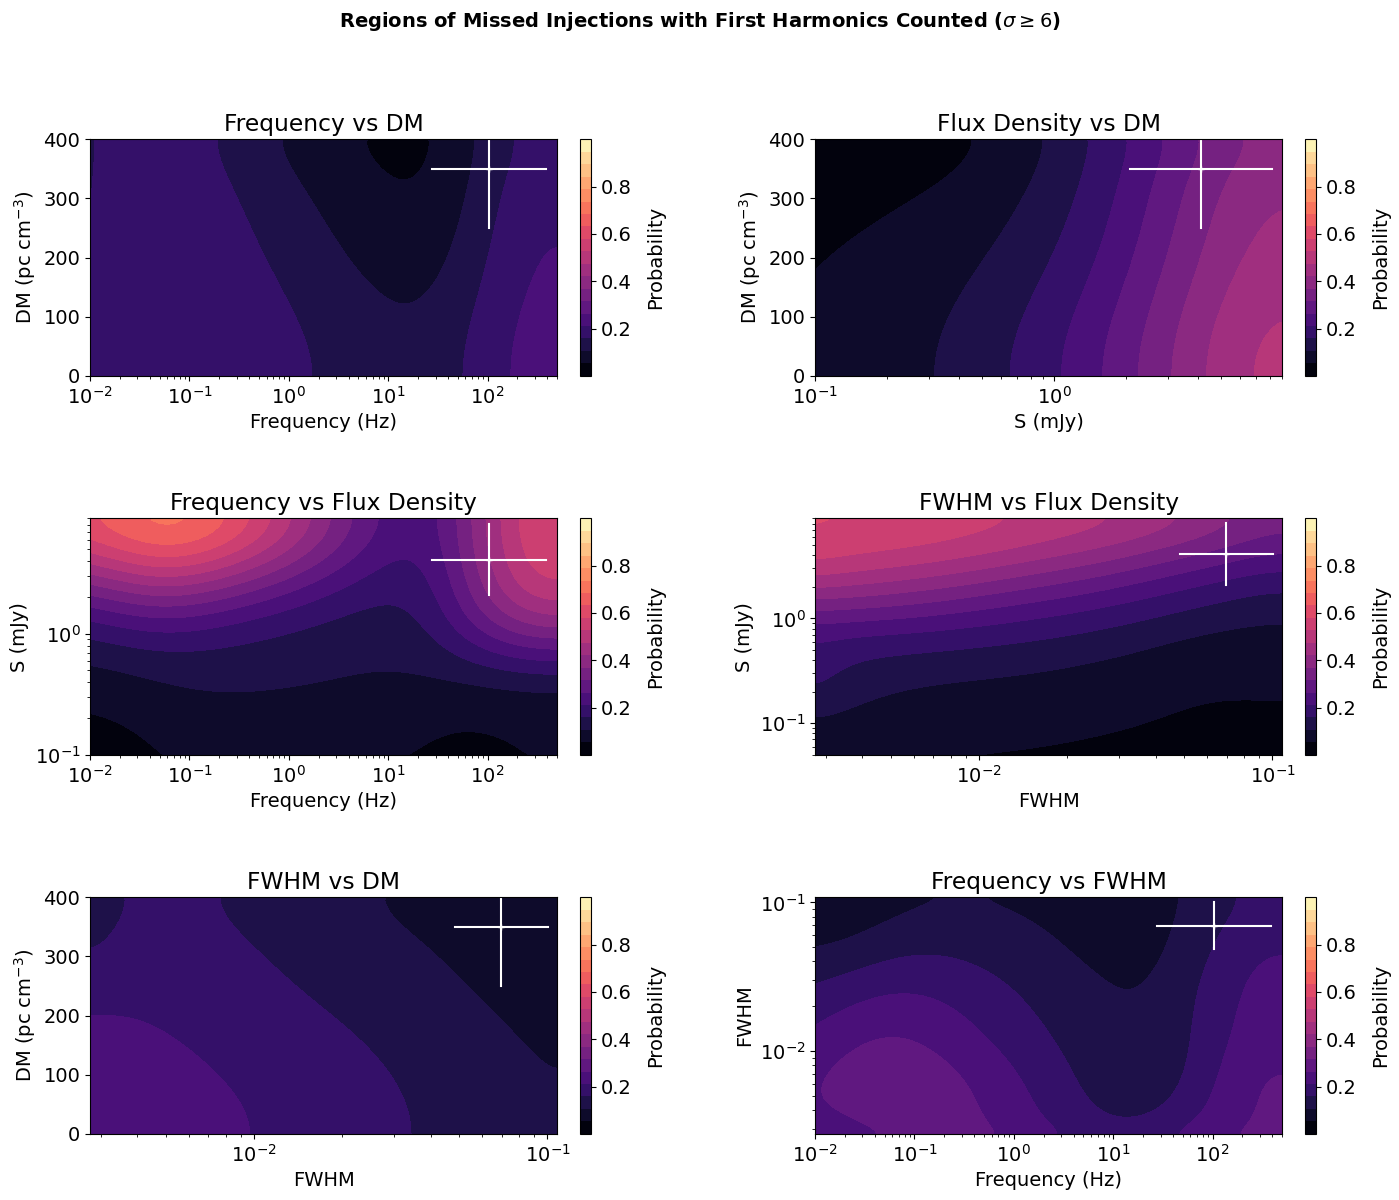

In [45]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

#f vs DM
cf0 = axes[0, 0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_miss_p, 
                           levels=make_levels(dm_f_miss_p),cmap='magma')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('Frequency (Hz)')
axes[0, 0].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[0, 0].set_title('Frequency vs DM')
axes[0, 0].set_xlim(1e-2, max(f_bins))
axes[0, 0].set_ylim(0, 400)
add_colorbar(fig, axes[0, 0], cf0, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[0, 0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = axes[0, 1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_miss_p, 
                           levels=make_levels(dm_s_miss_p), cmap='magma')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel('S (mJy)')
axes[0, 1].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[0, 1].set_title('Flux Density vs DM')
axes[0, 1].set_xlim(1e-1, max(S_bins) - 1)
axes[0, 1].set_ylim(0, 400)
add_colorbar(fig, axes[0, 1], cf1, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[0, 1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#S vs f
cf2 = axes[1, 0].contourf(f_bins[:-1], S_bins[:-1], s_f_miss_p, 
                           levels=make_levels(s_f_miss_p), cmap='magma')
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('S (mJy)')
axes[1, 0].set_title('Frequency vs Flux Density')
axes[1, 0].set_xlim(1e-2, max(f_bins))
axes[1, 0].set_ylim(1e-1, max(S_bins) - 1)
add_colorbar(fig, axes[1, 0], cf2, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[1, 0], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = axes[1, 1].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_miss_p, 
                           levels=make_levels(s_fwhm_miss_p), cmap='magma')
axes[1, 1].set_xscale('log')
axes[1, 1].set_yscale('log')
axes[1, 1].set_xlabel('FWHM')
axes[1, 1].set_ylabel('S (mJy)')
axes[1, 1].set_title('FWHM vs Flux Density')
axes[1, 1].set_ylim(5e-2, max(S_bins) -1 )
add_colorbar(fig, axes[1, 1], cf3, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[1, 1], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = axes[2, 0].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_miss_p, 
                           levels=make_levels(dm_fwhm_miss_p), cmap='magma')
axes[2, 0].set_xscale('log')
axes[2, 0].set_xlabel('FWHM')
axes[2, 0].set_ylabel(r'DM (pc cm$^{-3}$)')
axes[2, 0].set_title('FWHM vs DM')
axes[2, 0].set_ylim(0, 400)
add_colorbar(fig, axes[2, 0], cf4, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[2, 0], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = axes[2, 1].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_miss_p, 
                           levels=make_levels(fwhm_f_miss_p), cmap='magma')
axes[2, 1].set_xscale('log')
axes[2, 1].set_yscale('log')
axes[2, 1].set_xlabel('Frequency (Hz)')
axes[2, 1].set_ylabel('FWHM')
axes[2, 1].set_title('Frequency vs FWHM')
axes[2, 1].set_xlim(1e-2, max(f_bins))
add_colorbar(fig, axes[2, 1], cf5, tick_locs = [0.2, 0.4, 0.6, 0.8])
add_crosshair(axes[2, 1], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

fig.suptitle(r'Regions of Missed Injections with First Harmonics Counted ($\sigma \geq 6$)', 
             fontsize=14, fontweight='bold')
fig.get_layout_engine().set(h_pad=0.1, hspace=0.15, w_pad=0.1, wspace=0.1, 
                            rect=[0, 0, 1, 0.95])

plt.show()

In [28]:
freq_mask_low = data[:, 4] < 1e-1
flux_mask = data[:, 6] > 1e0
sigma_mask = data[:, 8] > 6
detection_mask = data[:, -1] < 0
data1 = data[freq_mask_low & flux_mask & sigma_mask & detection_mask]
print('RA   Dec    Date      f    predicted sigma')
for i in range(len(data1)):
    print(f'{data1[i, 0]:.2f} {data1[i, 1]:.2f} {int(data1[i, 2])} {data1[i, 4]:.3f} {data1[i, 8]:.2f}')

RA   Dec    Date      f    predicted sigma
4.55 -10.03 20251119 0.036 7.65
341.73 3.39 20251119 0.035 8.32
146.53 -8.33 20251119 0.002 40.38
76.81 -9.19 20251119 0.002 9.25
342.69 3.39 20251119 0.009 30.60
216.84 3.03 20251119 0.065 19.07
148.80 -8.33 20251119 0.017 7.59
345.90 3.38 20251119 0.003 6.31
218.44 3.03 20251119 0.009 9.22
150.09 -8.33 20251119 0.027 58.13
150.09 -8.33 20251119 0.023 22.30
150.41 -8.33 20251119 0.024 6.24
150.41 -8.33 20251119 0.003 7.70
79.73 -9.18 20251119 0.016 6.44
219.08 3.03 20251119 0.012 16.28
80.05 -9.18 20251119 0.002 30.06
219.40 3.03 20251119 0.004 8.24
10.72 -10.03 20251119 0.044 7.23


In [29]:
freq_mask_hi = data[:, 4] > 1e2
flux_mask = data[:, 6] > 1e0
sigma_mask = data[:, 8] > 6
detection_mask = data[:, -1] < 0
data2 = data[freq_mask_hi & flux_mask & sigma_mask & detection_mask]
print('RA   Dec    Date      f    predicted sigma')
for i in range(len(data1)):
    print(f'{data2[i, 0]} {data2[i, 1]} {int(data2[i, 2])} {data2[i, 3]} {data2[i, 4]} {data2[i, 5]} \
          {data2[i, 6]} {data2[i, 7]} {data2[i, 8]} {data2[i, 9]} {data2[i, 10]} {data2[i, 11]} \
            {data2[i, 12]} {data2[i, 13]}')

RA   Dec    Date      f    predicted sigma
74.54 -9.2 20251119 1116.0 311.52648 81.57610442136759           3.4942529093140577 0.01520659744487199 36.93351392978536 1.0 -1.0 -1.0             -1.0 -1.0
340.77 3.39 20251119 577.0 258.58602012374683 107.2147438675767           4.042599017082547 0.019353851293473442 23.14045937522312 1.0 -1.0 -1.0             -1.0 -1.0
145.24 -8.33 20251119 219.0 475.3568747441 102.17383129270826           2.5605946519140703 0.016589015394405805 14.83469681735493 1.0 -1.0 -1.0             -1.0 -1.0
145.56 -8.33 20251119 1027.0 494.3250341583081 152.71530463350177           2.5412096979365755 0.03041319488974398 10.270868441842532 1.0 -1.0 -1.0             -1.0 -1.0
4.87 -10.03 20251119 8.0 276.59755044807 111.38344276732394           2.3358063980337582 0.02350110514207489 10.802755220989196 1.0 -1.0 -1.0             -1.0 -1.0
5.19 -10.03 20251119 316.0 196.27145538862112 0.0           2.7135845277589143 0.04147253848601452 16.84660299432348 2.0 -1.0 -1.0  